# 2. Exploratory Data Analysis

## Dataset Overview

### Data Source
For this analysis the result of data preparation dataframe will be used. It already has all the basic corrections done.

### Dataset Description

**Table: rest_data**

| Column | Description |
|--------|-------------|
| `id` |  Restaurant establishment unique id |
| `object_name` |  Restaurant establishment name |
| `address` | Full address of the establishment |
| `chain` | Whether the establishment is part of a chain (TRUE/FALSE) |
| `object_type` | Type of establishment (e.g., restaurant, cafe, bar) |
| `number` | Number of seats in the establishment |


## Objectives

1. Investigate the proportions of different establishment types
2. Investigate chain vs non-chain proportions
3. Identify which establishment type is typical for chains
4. Analyze what characterizes chains: many establishments with few seats or few establishments with many seats
5. Determine the average number of seats per establishment type
6. Extract street names from the address column
7. Find the top 10 streets with the most restaurants
8. Find the number of streets with only one restaurant
9. Analyze the seat distribution for streets with many restaurants
10. Draw overall conclusions and recommendations

In [2]:
# Importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Reading cleaned data
rest_data = pd.read_csv("../data/rest_data_cleaned.csv",
                        dtype={"object_type": "category"})

In [4]:
# Checking df informations
rest_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   id           9648 non-null   int64   
 1   object_name  9648 non-null   str     
 2   address      9648 non-null   str     
 3   chain        9648 non-null   bool    
 4   object_type  9648 non-null   category
 5   number       9648 non-null   int64   
dtypes: bool(1), category(1), int64(2), str(2)
memory usage: 320.7 KB


## 2.1 Establishment type proportions

In [5]:
# Getting total number of establishments
total_estab = rest_data['object_type'].count()

In [6]:
# Get establishments count by type
estab_types = rest_data['object_type'].value_counts().reset_index()

In [7]:
# Adding proportion column
estab_types['proportion'] = estab_types['count'] / total_estab * 100

In [8]:
# Checking results
estab_types

,object_type,count,proportion
0,Restaurant,7253,75.176202
1,Fast Food,1066,11.048922
2,Cafe,435,4.508706
3,Pizza,319,3.306385
4,Bar,292,3.026534
5,Bakery,283,2.933250


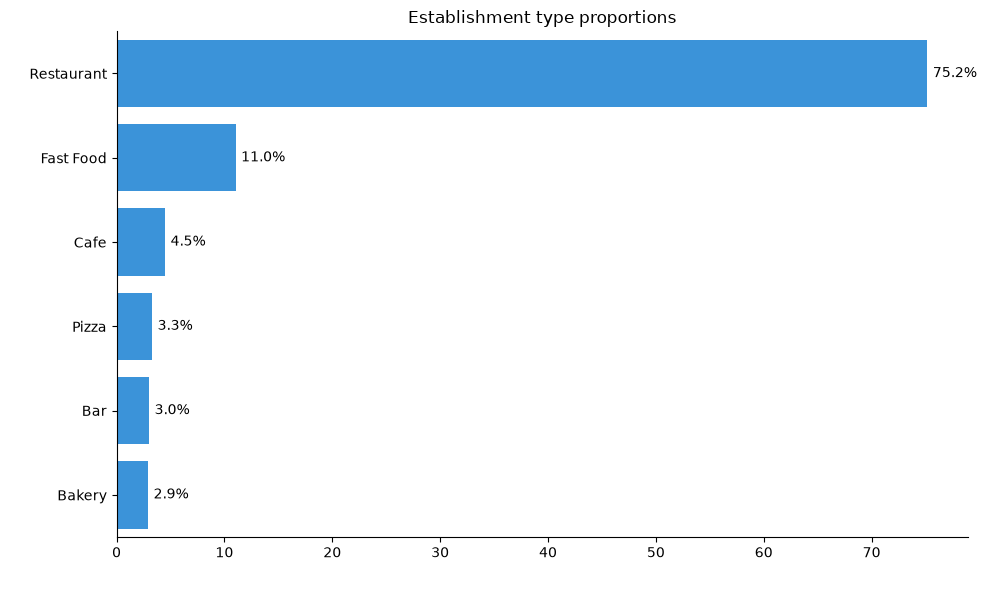

In [9]:
# Ploting H barchart
plt.figure(figsize=(10, 6))


ax = sns.barplot(y="object_type", x="proportion",
                 data=estab_types, order=estab_types['object_type'],
                 color="#2196F3")

for i, val in enumerate(estab_types['proportion']):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center')


ax.set_title('Establishment type proportions')
ax.set_xlabel(' ')
ax.set_ylabel(' ')

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation

The bar chart reveals a **highly concentrated market** dominated by traditional restaurants:

- **Restaurants** account for **75.2%** of all establishments, making them the overwhelming majority
- **Fast Food** follows distantly with **11.0%**, the only other significant category
- Other types (**Cafes, Pizza, Bars, Bakeries**) are niche segments, each representing less than 5%

**Key Insight:** The LA market is heavily skewed towards full-service restaurants. The limited presence of cafes (4.5%) could indicate a market gap for a casual dining concept like a robot-staffed cafeteria.

## 2.2 Establishment chain (or not) proportions

In [10]:
# Get chain or not chain count
chain_stats = rest_data['chain'].value_counts().reset_index()

In [11]:
# Calculating proportions
chain_stats['chain_proportion'] = chain_stats['count'] / total_estab * 100

In [12]:
chain_stats.columns = ['is_chain', 'total', 'chain_proportion']

In [13]:
chain_stats['is_chain'] = chain_stats['is_chain'].replace(
    {False: 'Non-Chain', True: 'Chain'})

In [14]:
# Checking results
chain_stats

,is_chain,total,chain_proportion
0,Non-Chain,5972,61.898839
1,Chain,3676,38.101161


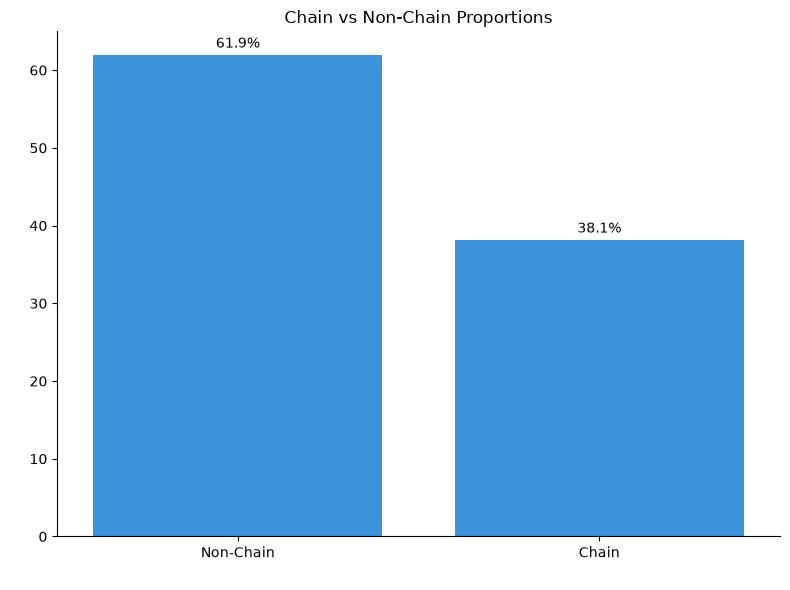

In [15]:
plt.figure(figsize=(8, 6))


ax = sns.barplot(x="is_chain", y="chain_proportion",
                 data=chain_stats, color="#2196F3")

for i, val in enumerate(chain_stats['chain_proportion']):
    ax.text(i, val + 1, f'{val:.1f}%', ha='center')


ax.set_title('Chain vs Non-Chain Proportions')
ax.set_xlabel(' ')
ax.set_ylabel(' ')

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation

Nearly **62% of establishments are independent**, while **38% belong to chains** — a significant share.

**Key Insight:** The strong chain presence (38%) shows that scalable concepts work well in LA, which is a good sign for a robot-staffed cafeteria that could easily replicate across locations.

## 2.3 Chain percentage by establishment type

In [16]:
# Calculate chain percentage for each establishment type
chain_by_type = rest_data.groupby('object_type')['chain'].mean() * 100
chain_by_type = chain_by_type.sort_values(ascending=False).reset_index()
chain_by_type.columns = ['object_type', 'chain_pct']
chain_by_type

,object_type,chain_pct
0,Bakery,100.000000
1,Cafe,61.149425
2,Fast Food,56.754221
3,Pizza,47.962382
4,Restaurant,31.600717
5,Bar,26.369863


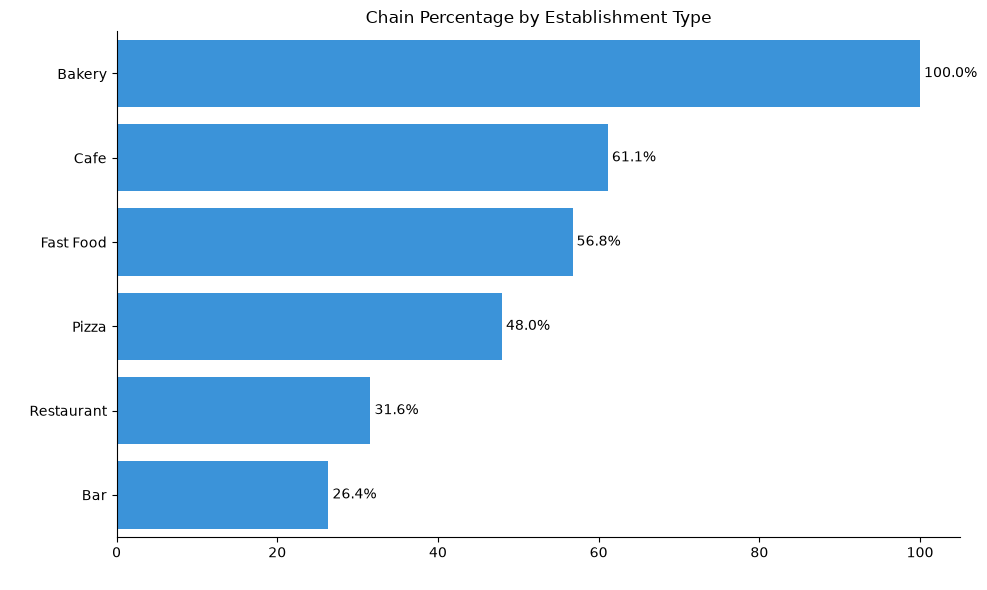

In [19]:
# Plotting chain percentage by establishment type
plt.figure(figsize=(10, 6))

ax = sns.barplot(y="object_type", x="chain_pct",
                 data=chain_by_type, order=chain_by_type['object_type'],
                 color="#2196F3")

for i, val in enumerate(chain_by_type['chain_pct']):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center')

ax.set_title('Chain Percentage by Establishment Type')
ax.set_xlabel(' ')
ax.set_ylabel(' ')

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation

The chart shows the percentage of each establishment type that belongs to a chain:

- **Bakery** stands out with **100%** being chains — every bakery in the dataset is part of a chain
- **Cafe (61.1%)** and **Fast Food (56.8%)** also have a strong chain presence, meaning these types scale well as chain businesses
- **Restaurants (31.6%)** and **Bars (26.4%)** are the least chain-oriented, tending to be more independent

**Key Insight:** Cafes have a high chain rate (61%), which shows that the cafe model is well suited for chain operations. This is a positive sign for a robot-staffed cafeteria concept, as the market already supports scalable cafe chains.